#**Sentiment Analysis Classifiers and Embeddings for Relive App Review**

Sentiment Analysis on dataset using different classifiers such as LinearSVM, LogisticRegression, NaiveBayes, XGBoost, RandomForest with different kind of embeddings such as TF-IDF, USE, and TF-IDF+USE. A continuation from the review scraping in `04-relive-reviews-exploratory-data-analysis.ipynb`, which you can access [here](https://colab.research.google.com/drive/1GIO8ch4BaGwC5zDlr2ulOjXwqZ_6yHjS?usp=sharing)

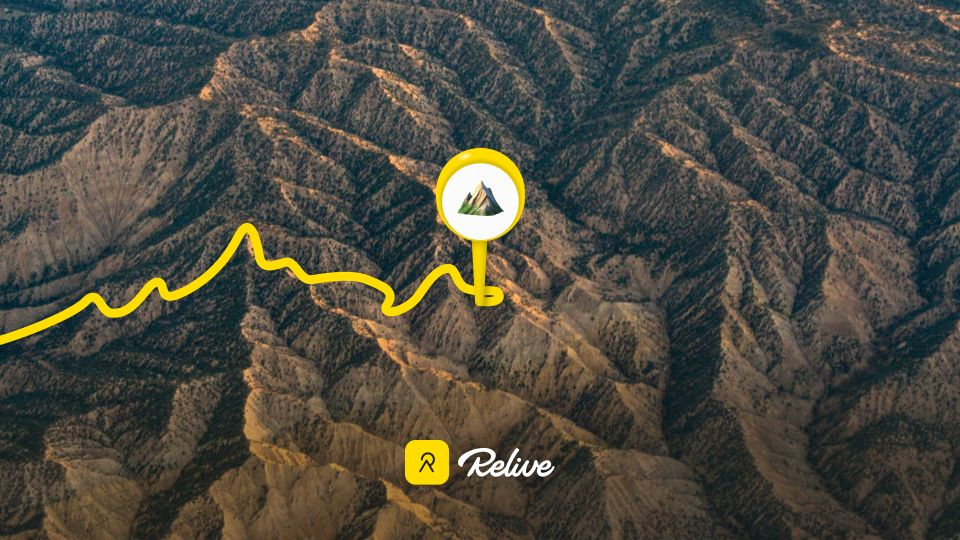

---



#### Installing and importing libraries

In [1]:
pip install -U nltk

In [2]:
pip install tensorflow_hub

In [ ]:
#pip install torch

In [ ]:
#pip install xgboost

In [3]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [4]:
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
stop_words = set(stopwords.words('english'))

#### To check is there any GPU available or not

In [7]:
is_cuda = torch.cuda.is_available()

# If we have a GPU available, we'll set our device to GPU.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")


GPU is available


#### Load the df_reliverev dataset for sentiment analysis between positive and negative reviews

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np


Mounted at /content/drive


In [9]:
df_reliverev_sentiment = pd.read_csv('/content/drive/My Drive/Data/df_reliverev_sentiment')
df_reliverev_sentiment

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,tokenized_content,lower_tokenized_content,removed_stopwords_content,...,stemmed_content,cleaned_content,expanded_cleaned_content,spell_corrected_content,spell_corrected_content_no_rare,spell_corrected_content_no_rare_no_common,word_difference,sentiment_polarity,sentiment_subjective,sentiment_rating
0,71f966cc-b905-4d92-9662-267512516332,"Good app, but I wish for upgrade in UI and som...",4,0,2025-03-11 11:58:45,NaN,NaN,"['Good', 'app', ',', 'but', 'I', 'wish', 'for'...","['good', 'app', ',', 'but', 'i', 'wish', 'for'...","['good', 'app', ',', 'wish', 'upgrade', 'ui', ...",...,"['good', 'app', ',', 'wish', 'upgrad', 'ui', '...",good app wish upgrad ui featur soon,good app wish upgrad ui featur soon,good app wish upgrade i feature soon,good app wish upgrade i feature soon,good app wish upgrade feature soon,{'i'},0.7,0.600000,Positive
1,7554edbe-d8bc-4a4a-aaa7-3d9c7112a493,accurate details,4,0,2025-03-11 00:24:19,NaN,NaN,"['accurate', 'details']","['accurate', 'details']","['accurate', 'details']",...,"['accur', 'detail']",accur detail,accur detail,occur detail,occur,occur,set(),0.0,0.000000,Positive
2,2eaa87c0-38d1-4a23-a7c7-81a74dda90ca,"Paid for this last year at 50% off, its just r...",2,0,2025-03-10 14:14:45,NaN,NaN,"['Paid', 'for', 'this', 'last', 'year', 'at', ...","['paid', 'for', 'this', 'last', 'year', 'at', ...","['paid', 'last', 'year', '50', '%', ',', 'rene...",...,"['paid', 'last', 'year', '50', '%', ',', 'rene...",paid last year 50 renew £32 warn whatsoev r...,paid last year 50 renew £32 warn whatsoev r...,paid last year renew warn whatsoever refund ac...,paid last year refund email absolute,paid last year refund email absolute,set(),0.1,0.483333,Negative
3,bfecffd5-233c-48c0-8b70-7fc1cf66912a,"It's a very good application for me, so try it...",5,0,2025-03-10 12:45:46,NaN,NaN,"['It', ""'s"", 'a', 'very', 'good', 'application...","['it', ""'s"", 'a', 'very', 'good', 'application...","[""'s"", 'good', 'application', ',', 'try', 'fol...",...,"[""'s"", 'good', 'applic', ',', 'tri', 'folk']",s good applic tri folk,s good applic tri folk,a good apply try folk,a good apply try,good apply try,{'a'},0.7,0.600000,Positive
4,d238c089-b972-4155-abdb-b26a5f285134,Ohsem,5,0,2025-03-09 05:45:56,NaN,NaN,['Ohsem'],['ohsem'],['ohsem'],...,['ohsem'],ohsem,ohsem,them,NaN,NaN,set(),0.0,0.000000,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21614,bf98d323-2b31-4df8-a3f7-446e0d00748e,Awesome.. has all my rides,5,0,2017-03-26 05:55:08,NaN,NaN,"['Awesome', '..', 'has', 'all', 'my', 'rides']","['awesome', '..', 'has', 'all', 'my', 'rides']","['awesome', '..', 'rides']",...,"['awesom', '..', 'ride']",awesom ride,awesom ride,awesome ride,awesome ride,awesome ride,set(),1.0,1.000000,Positive
21615,903af083-7b12-4708-bc25-31c779b4ff6d,"So far, very good.",5,0,2017-03-26 01:39:03,NaN,NaN,"['So', 'far', ',', 'very', 'good', '.']","['so', 'far', ',', 'very', 'good', '.']","['far', ',', 'good', '.']",...,"['far', ',', 'good', '.']",far good,far good,far good,far good,far good,set(),0.4,0.800000,Positive
21616,44ed2bef-eca5-4b36-93e2-dde154698632,Love the app. Fantastic....,5,0,2017-03-25 08:24:47,NaN,NaN,"['Love', 'the', 'app', '.', 'Fantastic', '....']","['love', 'the', 'app', '.', 'fantastic', '....']","['love', 'app', '.', 'fantastic', '....']",...,"['love', 'app', '.', 'fantast', '....']",love app fantast,love app fantast,love app fantast,love app fantast,love app fantast,set(),0.5,0.600000,Positive
21617,a77422c6-b008-484f-a1a8-5a816fbd9397,"Brilliant, just what was needed adding the app...",5,1,2017-03-23 18:20:09,NaN,NaN,"['Brilliant', ',', 'just', 'what', 'was', 'nee...","['brilliant', ',', 'just', 'what', 'was', 'nee...","['brilliant', ',', 'needed', 'adding', 'app', ...",...,"['brilliant', ',', 'need', 'ad', 'app', '.', '...",brilliant need ad app noth prais team reliv ...,brilliant need ad app noth prais team reliv ...,brill

In [10]:
#rename nama kolom
df_reliverev_sentiment = df_reliverev_sentiment.rename(columns={"cleaned_content": "no_punctional_content","expanded_cleaned_content": "no_punctional_expanded_content","spell_corrected_content_no_rare_no_common": "cleaned_content", "sentiment_rating": "sentiment"})


In [ ]:
df_reliverev_sentiment

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,tokenized_content,lower_tokenized_content,removed_stopwords_content,...,stemmed_content,no_punctional_content,no_punctional_expanded_content,spell_corrected_content,spell_corrected_content_no_rare,cleaned_content,word_difference,sentiment_polarity,sentiment_subjective,sentiment
0,71f966cc-b905-4d92-9662-267512516332,"Good app, but I wish for upgrade in UI and som...",4,0,2025-03-11 11:58:45,NaN,NaN,"['Good', 'app', ',', 'but', 'I', 'wish', 'for'...","['good', 'app', ',', 'but', 'i', 'wish', 'for'...","['good', 'app', ',', 'wish', 'upgrade', 'ui', ...",...,"['good', 'app', ',', 'wish', 'upgrad', 'ui', '...",good app wish upgrad ui featur soon,good app wish upgrad ui featur soon,good app wish upgrade i feature soon,good app wish upgrade i feature soon,good app wish upgrade feature soon,{'i'},0.7,0.600000,Positive
1,7554edbe-d8bc-4a4a-aaa7-3d9c7112a493,accurate details,4,0,2025-03-11 00:24:19,NaN,NaN,"['accurate', 'details']","['accurate', 'details']","['accurate', 'details']",...,"['accur', 'detail']",accur detail,accur detail,occur detail,occur,occur,set(),0.0,0.000000,Positive
2,2eaa87c0-38d1-4a23-a7c7-81a74dda90ca,"Paid for this last year at 50% off, its just r...",2,0,2025-03-10 14:14:45,NaN,NaN,"['Paid', 'for', 'this', 'last', 'year', 'at', ...","['paid', 'for', 'this', 'last', 'year', 'at', ...","['paid', 'last', 'year', '50', '%', ',', 'rene...",...,"['paid', 'last', 'year', '50', '%', ',', 'rene...",paid last year 50 renew £32 warn whatsoev r...,paid last year 50 renew £32 warn whatsoev r...,paid last year renew warn whatsoever refund ac...,paid last year refund email absolute,paid last year refund email absolute,set(),0.1,0.483333,Negative
3,bfecffd5-233c-48c0-8b70-7fc1cf66912a,"It's a very good application for me, so try it...",5,0,2025-03-10 12:45:46,NaN,NaN,"['It', ""'s"", 'a', 'very', 'good', 'application...","['it', ""'s"", 'a', 'very', 'good', 'application...","[""'s"", 'good', 'application', ',', 'try', 'fol...",...,"[""'s"", 'good', 'applic', ',', 'tri', 'folk']",s good applic tri folk,s good applic tri folk,a good apply try folk,a good apply try,good apply try,{'a'},0.7,0.600000,Positive
4,d238c089-b972-4155-abdb-b26a5f285134,Ohsem,5,0,2025-03-09 05:45:56,NaN,NaN,['Ohsem'],['ohsem'],['ohsem'],...,['ohsem'],ohsem,ohsem,them,NaN,NaN,set(),0.0,0.000000,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21614,bf98d323-2b31-4df8-a3f7-446e0d00748e,Awesome.. has all my rides,5,0,2017-03-26 05:55:08,NaN,NaN,"['Awesome', '..', 'has', 'all', 'my', 'rides']","['awesome', '..', 'has', 'all', 'my', 'rides']","['awesome', '..', 'rides']",...,"['awesom', '..', 'ride']",awesom ride,awesom ride,awesome ride,awesome ride,awesome ride,set(),1.0,1.000000,Positive
21615,903af083-7b12-4708-bc25-31c779b4ff6d,"So far, very good.",5,0,2017-03-26 01:39:03,NaN,NaN,"['So', 'far', ',', 'very', 'good', '.']","['so', 'far', ',', 'very', 'good', '.']","['far', ',', 'good', '.']",...,"['far', ',', 'good', '.']",far good,far good,far good,far good,far good,set(),0.4,0.800000,Positive
21616,44ed2bef-eca5-4b36-93e2-dde154698632,Love the app. Fantastic....,5,0,2017-03-25 08:24:47,NaN,NaN,"['Love', 'the', 'app', '.', 'Fantastic', '....']","['love', 'the', 'app', '.', 'fantastic', '....']","['love', 'app', '.', 'fantastic', '....']",...,"['love', 'app', '.', 'fantast', '....']",love app fantast,love app fantast,love app fantast,love app fantast,love app fantast,set(),0.5,0.600000,Positive
21617,a77422c6-b008-484f-a1a8-5a816fbd9397,"Brilliant, just what was needed adding the app...",5,1,2017-03-23 18:20:09,NaN,NaN,"['Brilliant', ',', 'just', 'what', 'was', 'nee...","['brilliant', ',', 'just', 'what', 'was', 'nee...","['brilliant', ',', 'needed', 'adding', 'app', ...",...,"['brilliant', ',', 'need', 'ad', 'app', '.', '...",brilliant need ad app noth prais team reliv ...,brilliant need ad app noth prais team reliv ...,brilliant need and app not

In [12]:
df_reliverev_sentiment.dropna(subset=['cleaned_content', 'sentiment'])

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,tokenized_content,lower_tokenized_content,removed_stopwords_content,...,stemmed_content,no_punctional_content,no_punctional_expanded_content,spell_corrected_content,spell_corrected_content_no_rare,cleaned_content,word_difference,sentiment_polarity,sentiment_subjective,sentiment
0,71f966cc-b905-4d92-9662-267512516332,"Good app, but I wish for upgrade in UI and som...",4,0,2025-03-11 11:58:45,NaN,NaN,"['Good', 'app', ',', 'but', 'I', 'wish', 'for'...","['good', 'app', ',', 'but', 'i', 'wish', 'for'...","['good', 'app', ',', 'wish', 'upgrade', 'ui', ...",...,"['good', 'app', ',', 'wish', 'upgrad', 'ui', '...",good app wish upgrad ui featur soon,good app wish upgrad ui featur soon,good app wish upgrade i feature soon,good app wish upgrade i feature soon,good app wish upgrade feature soon,{'i'},0.7,0.600000,Positive
1,7554edbe-d8bc-4a4a-aaa7-3d9c7112a493,accurate details,4,0,2025-03-11 00:24:19,NaN,NaN,"['accurate', 'details']","['accurate', 'details']","['accurate', 'details']",...,"['accur', 'detail']",accur detail,accur detail,occur detail,occur,occur,set(),0.0,0.000000,Positive
2,2eaa87c0-38d1-4a23-a7c7-81a74dda90ca,"Paid for this last year at 50% off, its just r...",2,0,2025-03-10 14:14:45,NaN,NaN,"['Paid', 'for', 'this', 'last', 'year', 'at', ...","['paid', 'for', 'this', 'last', 'year', 'at', ...","['paid', 'last', 'year', '50', '%', ',', 'rene...",...,"['paid', 'last', 'year', '50', '%', ',', 'rene...",paid last year 50 renew £32 warn whatsoev r...,paid last year 50 renew £32 warn whatsoev r...,paid last year renew warn whatsoever refund ac...,paid last year refund email absolute,paid last year refund email absolute,set(),0.1,0.483333,Negative
3,bfecffd5-233c-48c0-8b70-7fc1cf66912a,"It's a very good application for me, so try it...",5,0,2025-03-10 12:45:46,NaN,NaN,"['It', ""'s"", 'a', 'very', 'good', 'application...","['it', ""'s"", 'a', 'very', 'good', 'application...","[""'s"", 'good', 'application', ',', 'try', 'fol...",...,"[""'s"", 'good', 'applic', ',', 'tri', 'folk']",s good applic tri folk,s good applic tri folk,a good apply try folk,a good apply try,good apply try,{'a'},0.7,0.600000,Positive
5,ef454f4a-e991-4eb6-9216-0e56e9717a36,I keep getting emails from this company even t...,1,0,2025-03-08 02:34:04,NaN,NaN,"['I', 'keep', 'getting', 'emails', 'from', 'th...","['i', 'keep', 'getting', 'emails', 'from', 'th...","['keep', 'getting', 'emails', 'company', 'even...",...,"['keep', 'get', 'email', 'compani', 'even', 't...",keep get email compani even though ve unsucrib...,keep get email compani even though ve unsucrib...,keep get email company even though be unsubscr...,keep get email even though be time relic get s...,keep get email even though time relic get stop...,{'be'},0.0,0.000000,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21614,bf98d323-2b31-4df8-a3f7-446e0d00748e,Awesome.. has all my rides,5,0,2017-03-26 05:55:08,NaN,NaN,"['Awesome', '..', 'has', 'all', 'my', 'rides']","['awesome', '..', 'has', 'all', 'my', 'rides']","['awesome', '..', 'rides']",...,"['awesom', '..', 'ride']",awesom ride,awesom ride,awesome ride,awesome ride,awesome ride,set(),1.0,1.000000,Positive
21615,903af083-7b12-4708-bc25-31c779b4ff6d,"So far, very good.",5,0,2017-03-26 01:39:03,NaN,NaN,"['So', 'far', ',', 'very', 'good', '.']","['so', 'far', ',', 'very', 'good', '.']","['far', ',', 'good', '.']",...,"['far', ',', 'good', '.']",far good,far good,far good,far good,far good,set(),0.4,0.800000,Positive
21616,44ed2bef-eca5-4b36-93e2-dde154698632,Love the app. Fantastic....,5,0,2017-03-25 08:24:47,NaN,NaN,"['Love', 'the', 'app', '.', 'Fantastic', '....']","['love', 'the', 'app', '.', 'fantastic', '....']","['love', 'app', '.', 'fantastic', '....']",...,"['love', 'app', '.', 'fantast', '....']",love app fantast,love app fantast,love app fantast,love app fantast,love app fantast,set(),0.5,0.600000,Positive
21617,a77422c6-b008-484

#### Split x=feature, y=target

In [13]:
x = df_reliverev_sentiment['cleaned_content']
y = df_reliverev_sentiment['sentiment']

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encode = LabelEncoder()
# Menggunakan df_reliverev_sentiment['sentiment'] langsung untuk Y
Y_encoded = label_encode.fit_transform(df_reliverev_sentiment['sentiment'])
Y_encoded

array([2, 2, 0, ..., 2, 2, 2])

In [15]:
CLASS_NAMES = list(label_encode.classes_)
print(f"Mapping LabelEncoder: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}")
print(f"Total number of classes: {len(CLASS_NAMES)}")

Mapping LabelEncoder: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Total number of classes: 3


In [16]:
# Buat DataFrame sementara untuk memudahkan filtering yang konsisten
temp_df = pd.DataFrame({
    'content': df_reliverev_sentiment['cleaned_content'],
    'sentiment_encoded': Y_encoded
})

In [23]:
# Filter baris yang kontennya valid (bukan NaN, bukan string kosong)
# Pastikan juga untuk mengonversi ke string sebelum .strip()
temp_df_filtered = temp_df[
    temp_df['content'].notna() &
    (temp_df['content'].astype(str).str.strip() != '')
]

In [24]:
# Ambil kembali x dan Y yang sudah bersih
x_cleaned = temp_df_filtered['content']
Y_cleaned = temp_df_filtered['sentiment_encoded']

In [25]:
df_cleaned = pd.DataFrame({
    'cleaned_content': x_cleaned,
    'sentiment_encoded': Y_cleaned
})
# Tambahkan kolom sentiment asli DARI Y_CLEANED, bukan dari y awal
# Kita perlu mengonversi kembali Y_cleaned ke label aslinya jika ingin melihat 'Positive', 'Negative'
# Atau, jika kolom 'sentiment' (asli) memang harus ada, pastikan juga sudah difilter
df_cleaned['sentiment'] = label_encode.inverse_transform(Y_cleaned.astype(int))

df_cleaned.head(10)

,cleaned_content,sentiment_encoded,sentiment
0,good app wish upgrade feature soon,2,Positive
1,occur,2,Positive
2,paid last year refund email absolute,0,Negative
3,good apply try,2,Positive
5,keep get email even though time relic get stop...,0,Negative
6,get new music fix follow add option add sport ...,1,Neutral
7,amaze,2,Positive
9,great app,2,Positive
10,apply keep auto,1,Neutral
11,nice memory wish could photo play,2,Positive


### Split the dataset into training and testing sets


In [26]:
# Gunakan x_cleaned dan Y_cleaned yang sudah difilter untuk train-test split
xtrain_cleaned_split, xtest_cleaned_split, ytrain_cleaned_split, ytest_cleaned_split = train_test_split(x_cleaned, Y_cleaned, test_size=0.2, random_state=42, stratify=Y_cleaned)

# mencetak bentuk (shape) dari masing-masing set untuk memverifikasi
print(f"Shape of xtrain_cleaned_split: {xtrain_cleaned_split.shape}")
print(f"Shape of xtest_cleaned_split: {xtest_cleaned_split.shape}")
print(f"Shape of ytrain_cleaned_split: {ytrain_cleaned_split.shape}")
print(f"Shape of ytest_cleaned_split: {ytest_cleaned_split.shape}")

Shape of xtrain_cleaned_split: (15795,)
Shape of xtest_cleaned_split: (3949,)
Shape of ytrain_cleaned_split: (15795,)
Shape of ytest_cleaned_split: (3949,)


### Note: 0 represent negative comments and 1 neutral and 2 represent positive comments

### Create a vocabulary

In [27]:
# Create a vocabulary

from collections import Counter

# Menghitung frekuensi setiap kata dalam data pelatihan
# Kita menggabungkan semua teks dalam xtrain_cleaned_split menjadi satu string besar,
# kemudian memisahkannya menjadi kata-kata (split()) dan menghitung kemunculan setiap kata.
word_counts = Counter(' '.join(str(item) for item in xtrain_cleaned_split).split())

### Display each word in the vocabulary along with its count


In [28]:
for word, count in word_counts.items():
    print(f"{word}: {count}")

pretty: 101
cool: 618
app: 6241
great: 2404
video: 1127
hike: 160
relic: 553
refund: 65
cancel: 84
give: 176
notify: 45
charge: 86
automat: 52
year: 125
plus: 135
want: 160
taken: 59
pleas: 190
add: 268
watch: 110
connect: 193
tracker: 83
east: 664
use: 1688
turn: 54
amaze: 502
track: 579
trip: 176
photo: 336
make: 366
best: 687
map: 310
occur: 208
good: 2885
perfect: 287
useful: 59
outdoor: 80
expert: 173
work: 671
properly: 46
auto: 47
update: 163
google: 74
fit: 56
run: 328
android: 61
also: 223
miss: 46
free: 432
trial: 77
got: 79
subscript: 209
money: 73
stop: 163
rout: 314
active: 607
minute: 54
love: 1256
seem: 117
well: 202
done: 73
us: 66
ask: 65
rate: 46
know: 101
sure: 46
time: 574
far: 297
hour: 73
way: 375
nice: 1916
fantast: 201
problem: 111
save: 118
share: 275
adventure: 104
every: 161
really: 423
though: 78
signal: 81
data: 127
awesome: 1114
recommend: 134
total: 47
support: 87
speed: 117
music: 166
limit: 70
thank: 271
enjoy: 205
option: 186
get: 284
lost: 64
ride: 65

In [ ]:
#vocab = [word for word, count in word_counts.most_common()]
#vocab

### Classification with various classifiers
#### 1. Linear SVM
#### 2. Logistic Regression (LR)
#### 3. Naive Bayes
#### 4. XGBoost
#### 5. Random Forest

In [29]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

#### Initialize classifiers

In [30]:
# Menginisialisasi classifier dengan random_state untuk reproduktifitas
# dan parameter spesifik untuk XGBoost (objective dan num_class)
svm_classifier = LinearSVC(max_iter=2000, random_state=42) # Menambahkan max_iter dan random_state
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
nb_classifier = MultinomialNB()
# Untuk XGBoost, perlu objective dan num_class karena ini klasifikasi multi-kelas
xgboost_classifier = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', random_state=42, num_class=len(CLASS_NAMES)) # Menambahkan objective, eval_metric, num_class, dan random_state
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

In [31]:
def evaluate_model(model, xtest_data, ytest_labels, target_names=CLASS_NAMES):
    y_pred = model.predict(xtest_data)
    accuracy = accuracy_score(ytest_labels, y_pred)
    # Gunakan 'weighted' average untuk multi-kelas dengan potensi class imbalance
    precision = precision_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    recall = recall_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    report = classification_report(ytest_labels, y_pred, target_names=target_names, zero_division=0)
    cm = confusion_matrix(ytest_labels, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [32]:
# Define batch size
batch_size = 1000

## 1. TF-IDF
TF-IDF & Classification
1. Linear SVM
2. Logistic Regression
3. XGBoost classifier
4. Random Forest classifier

#### TF-IDF Vectorization


In [33]:
print("\n" + "="*80)
print("--- 1. EVALUASI MODEL DENGAN TF-IDF EMBEDDINGS SAJA ---")
print("="*80 + "\n")


--- 1. EVALUASI MODEL DENGAN TF-IDF EMBEDDINGS SAJA ---



In [34]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

In [35]:
tfidf_vectorizer.fit(xtrain_cleaned_split.tolist())

TfidfVectorizer(max_features=5000)

In [37]:
import numpy as np
from scipy.sparse import vstack # Import vstack untuk menggabungkan sparse matrices
from timeit import default_timer as timer

# Embedding TF-IDF untuk data train dengan batching
start = timer()
tfidf_vectorizer_xtrain_sparse_list = []
xtrain_list = xtrain_cleaned_split.tolist() # Gunakan xtrain_cleaned_split
for i in range(0, len(xtrain_list), batch_size):
    batch_X_train = xtrain_list[i:i + batch_size]
    batch_X_train_tfidf_sparse = tfidf_vectorizer.transform(batch_X_train)
    tfidf_vectorizer_xtrain_sparse_list.append(batch_X_train_tfidf_sparse)

# Menggabungkan semua sparse matrices ke dalam satu sparse matrix
tfidf_vectorizer_xtrain = vstack(tfidf_vectorizer_xtrain_sparse_list)
print('Waktu yang dibutuhkan untuk embedding TF-IDF pada data train:', timer() - start)

Waktu yang dibutuhkan untuk embedding TF-IDF pada data train: 0.12925588600000992


In [38]:
# Embedding TF-IDF untuk data test dengan batching
start = timer()
tfidf_vectorizer_xtest_sparse_list = []
xtest_list = xtest_cleaned_split.tolist()
for i in range(0, len(xtest_list), batch_size):
    batch_X_test = xtest_list[i:i + batch_size]
    batch_X_test_tfidf_sparse = tfidf_vectorizer.transform(batch_X_test)
    tfidf_vectorizer_xtest_sparse_list.append(batch_X_test_tfidf_sparse)

tfidf_vectorizer_xtest = vstack(tfidf_vectorizer_xtest_sparse_list)
print('Waktu yang dibutuhkan untuk embedding TF-IDF pada data test:', timer() - start)

Waktu yang dibutuhkan untuk embedding TF-IDF pada data test: 0.032118634999960705


In [39]:
# Cek tipe dan bentuk (shape)
print(type(tfidf_vectorizer_xtrain))
print(tfidf_vectorizer_xtrain.shape)

print(type(tfidf_vectorizer_xtest))
print(tfidf_vectorizer_xtest.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(15795, 298)
<class 'scipy.sparse._csr.csr_matrix'>
(3949, 298)


In [40]:
# Inisialisasi classifier (pastikan ini ada di sel inisialisasi classifier dengan parameter yang disepakati)
svm_classifier = LinearSVC(max_iter=2000, random_state=42)
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', random_state=42, num_class=len(CLASS_NAMES))
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

In [41]:
# Melatih model dan mengukur waktu yang dibutuhkan
start = timer()
svm_tfidf = svm_classifier.fit(tfidf_vectorizer_xtrain, ytrain_cleaned_split)
print('Required time for training Linear SVM classifier:', timer() - start)

start = timer()
lr_tfidf = logistic_regression.fit(tfidf_vectorizer_xtrain, ytrain_cleaned_split)
print('Required time for training Logistic Regression classifier:', timer() - start)

start = timer()
nb_tfidf = nb_classifier.fit(tfidf_vectorizer_xtrain, ytrain_cleaned_split)
print('Required time for training Naive Bayes classifier:', timer() - start)

start = timer()
xgboost_tfidf = xgboost_classifier.fit(tfidf_vectorizer_xtrain, ytrain_cleaned_split)
print('Required time for training XGBoost classifier:', timer() - start)

start = timer()
rfc_tfidf = random_forest_classifier.fit(tfidf_vectorizer_xtrain, ytrain_cleaned_split)
print('Required time for training Random Forest classifier:', timer() - start)

Required time for training Linear SVM classifier: 0.2861110119999921
Required time for training Logistic Regression classifier: 0.5786657940000168
Required time for training Naive Bayes classifier: 0.023203099999818733
Required time for training XGBoost classifier: 9.162381804999995
Required time for training Random Forest classifier: 0.4298541650000516


In [42]:
print("\n" + "="*80)
print("--- MAKE PREDICTION ---")
print("="*80 + "\n")


--- MAKE PREDICTION ---



### 1. Linear SVM TF-IDF

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("\n--- Evaluasi Linear SVM (TF-IDF) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan ytest_cleaned_split sebagai label aktual untuk pengujian
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, confusion_matrix_svm = \
    evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest_cleaned_split, target_names=CLASS_NAMES)
print('Waktu prediksi SVM:', timer() - start)


--- Evaluasi Linear SVM (TF-IDF) ---
Waktu prediksi SVM: 0.045706263000056424


In [45]:
# Print actual vs. predicted results for LinearSVM
## Menampilkan label kelas unik pada data testing
# Pastikan menggunakan ytest_cleaned_split untuk melihat label unik yang sudah bersih
print("\n=== Label Kelas yang Ada ===")
print(set(ytest_cleaned_split))


=== Label Kelas yang Ada ===
{0, 1, 2}


In [46]:
print("\nContoh 15 hasil prediksi SVM:")
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_svm[:15]):
    print(f"Aktual: {actual}, Prediksi SVM: {predicted}")


Contoh 15 hasil prediksi SVM:
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 0, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 1, Prediksi SVM: 0
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 2, Prediksi SVM: 2
Aktual: 1, Prediksi SVM: 0
Aktual: 2, Prediksi SVM: 2


In [47]:
# Menampilkan hasil evaluasi
print("\n=== Evaluasi SVM ===")
print(f"Akurasi SVM: {accuracy_svm:.4f}")
print(f"Presisi SVM: {precision_svm:.4f}")
print(f"Recall SVM: {recall_svm:.4f}")
print(f"Skor F1 SVM: {f1_svm:.4f}")

print("\n=== Laporan Klasifikasi SVM ===")
print(report_svm)

print("\n=== Matriks Kebingungan SVM ===")
print(confusion_matrix_svm)


=== Evaluasi SVM ===
Akurasi SVM: 0.9172
Presisi SVM: 0.8937
Recall SVM: 0.9172
Skor F1 SVM: 0.8996

=== Laporan Klasifikasi SVM ===
              precision    recall  f1-score   support

    Negative       0.68      0.64      0.66       351
     Neutral       0.33      0.02      0.04       152
    Positive       0.94      0.99      0.96      3446

    accuracy                           0.92      3949
   macro avg       0.65      0.55      0.55      3949
weighted avg       0.89      0.92      0.90      3949


=== Matriks Kebingungan SVM ===
[[ 223    3  125]
 [  58    3   91]
 [  47    3 3396]]


### 2. Logistic Regression TF IDF

In [48]:
print("\n--- Evaluasi Logistic Regression (TF-IDF) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan ytest_cleaned_split sebagai label aktual untuk pengujian
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = \
    evaluate_model(lr_tfidf, tfidf_vectorizer_xtest, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Logistic Regression: {timer() - start:.4f} seconds')



--- Evaluasi Logistic Regression (TF-IDF) ---
Waktu prediksi Logistic Regression: 0.0623 seconds


In [49]:
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_lr[:15]):
    print(f"Aktual: {actual}, Prediksi Logistic Regression: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 0, Prediksi Logistic Regression: 0
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 1, Prediksi Logistic Regression: 0
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 2, Prediksi Logistic Regression: 2
Aktual: 1, Prediksi Logistic Regression: 0
Aktual: 2, Prediksi Logistic Regression: 2


In [50]:
print(f"\nAkurasi Logistic Regression: {accuracy_lr:.4f}")
print(f"Presisi Logistic Regression: {precision_lr:.4f}")
print(f"Recall Logistic Regression: {recall_lr:.4f}")
print(f"Skor F1 Logistic Regression: {f1_lr:.4f}")
print("Laporan Klasifikasi:\n", report_lr)
print("Matriks Kebingungan:\n", cm_lr)
print("-" * 70)


Akurasi Logistic Regression: 0.9197
Presisi Logistic Regression: 0.8996
Recall Logistic Regression: 0.9197
Skor F1 Logistic Regression: 0.9028
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.70      0.65      0.67       351
     Neutral       0.42      0.03      0.06       152
    Positive       0.94      0.99      0.96      3446

    accuracy                           0.92      3949
   macro avg       0.68      0.56      0.57      3949
weighted avg       0.90      0.92      0.90      3949

Matriks Kebingungan:
 [[ 227    3  121]
 [  57    5   90]
 [  42    4 3400]]
----------------------------------------------------------------------


### 3. Naive Bayes TF IDF

In [51]:
print("\n--- Evaluasi Naive Bayes (TF-IDF) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan ytest_cleaned_split sebagai label aktual untuk pengujian
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = \
    evaluate_model(nb_tfidf, tfidf_vectorizer_xtest, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Naive Bayes: {timer() - start:.4f} seconds')


--- Evaluasi Naive Bayes (TF-IDF) ---
Waktu prediksi Naive Bayes: 0.0599 seconds


In [52]:
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_nb[:15]):
    print(f"Aktual: {actual}, Prediksi Naive Bayes: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 0, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 1, Prediksi Naive Bayes: 0
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 2, Prediksi Naive Bayes: 2
Aktual: 1, Prediksi Naive Bayes: 0
Aktual: 2, Prediksi Naive Bayes: 2


In [53]:
print(f"\nAkurasi Naive Bayes: {accuracy_nb:.4f}")
print(f"Presisi Naive Bayes: {precision_nb:.4f}")
print(f"Recall Naive Bayes: {recall_nb:.4f}")
print(f"Skor F1 Naive Bayes: {f1_nb:.4f}")
print("Laporan Klasifikasi:\n", report_nb)
print("Matriks Kebingungan:\n", cm_nb)
print("-" * 70)


Akurasi Naive Bayes: 0.9195
Presisi Naive Bayes: 0.9015
Recall Naive Bayes: 0.9195
Skor F1 Naive Bayes: 0.9013
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.70      0.64      0.67       351
     Neutral       0.50      0.02      0.04       152
    Positive       0.94      0.99      0.96      3446

    accuracy                           0.92      3949
   macro avg       0.71      0.55      0.56      3949
weighted avg       0.90      0.92      0.90      3949

Matriks Kebingungan:
 [[ 226    0  125]
 [  56    3   93]
 [  41    3 3402]]
----------------------------------------------------------------------


### 4. xgboost TF IDF

In [54]:
print("\n--- Evaluasi XGBoost Classifier (TF-IDF) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan ytest_cleaned_split sebagai label aktual untuk pengujian
y_pred_xgboost, accuracy_xgboost, precision_xgboost, recall_xgboost, f1_xgboost, report_xgboost, cm_xgboost = \
    evaluate_model(xgboost_tfidf, tfidf_vectorizer_xtest, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi XGBoost: {timer() - start:.4f} seconds')


--- Evaluasi XGBoost Classifier (TF-IDF) ---
Waktu prediksi XGBoost: 0.1580 seconds


In [55]:
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_xgboost[:15]):
    print(f"Aktual: {actual}, Prediksi XGBoost: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 0, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 1, Prediksi XGBoost: 0
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 2, Prediksi XGBoost: 2
Aktual: 1, Prediksi XGBoost: 0
Aktual: 2, Prediksi XGBoost: 2


In [56]:
print(f"\nAkurasi XGBoost: {accuracy_xgboost:.4f}")
print(f"Presisi XGBoost: {precision_xgboost:.4f}")
print(f"Recall XGBoost: {recall_xgboost:.4f}")
print(f"Skor F1 XGBoost: {f1_xgboost:.4f}\n")
print("Laporan Klasifikasi:\n", report_xgboost)
print("Matriks Kebingungan:\n", cm_xgboost)
print("-" * 70)


Akurasi XGBoost: 0.9149
Presisi XGBoost: 0.8907
Recall XGBoost: 0.9149
Skor F1 XGBoost: 0.8995

Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.72      0.60      0.66       351
     Neutral       0.24      0.05      0.09       152
    Positive       0.94      0.99      0.96      3446

    accuracy                           0.91      3949
   macro avg       0.63      0.55      0.57      3949
weighted avg       0.89      0.91      0.90      3949

Matriks Kebingungan:
 [[ 210   11  130]
 [  44    8  100]
 [  36   15 3395]]
----------------------------------------------------------------------


### 5. Random Forest TF IDF

In [57]:
print("\n--- Evaluasi Random Forest Classifier (TF-IDF) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan ytest_cleaned_split sebagai label aktual untuk pengujian
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = \
    evaluate_model(rfc_tfidf, tfidf_vectorizer_xtest, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Random Forest: {timer() - start:.4f} seconds')


--- Evaluasi Random Forest Classifier (TF-IDF) ---
Waktu prediksi Random Forest: 0.0734 seconds


In [58]:
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_rfc[:15]):
    print(f"Aktual: {actual}, Prediksi Random Forest: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 0, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 1, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2
Aktual: 1, Prediksi Random Forest: 2
Aktual: 2, Prediksi Random Forest: 2


In [59]:
print(f"\nAkurasi Random Forest: {accuracy_rfc:.4f}")
print(f"Presisi Random Forest: {precision_rfc:.4f}")
print(f"Recall Random Forest: {recall_rfc:.4f}")
print(f"Skor F1 Random Forest: {f1_rfc:.4f}")
print("Laporan Klasifikasi:\n", report_rfc)
print("Matriks Kebingungan:\n", cm_rfc)
print("-" * 70)


Akurasi Random Forest: 0.8726
Presisi Random Forest: 0.7615
Recall Random Forest: 0.8726
Skor F1 Random Forest: 0.8133
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       351
     Neutral       0.00      0.00      0.00       152
    Positive       0.87      1.00      0.93      3446

    accuracy                           0.87      3949
   macro avg       0.29      0.33      0.31      3949
weighted avg       0.76      0.87      0.81      3949

Matriks Kebingungan:
 [[   0    0  351]
 [   0    0  152]
 [   0    0 3446]]
----------------------------------------------------------------------


###Perbandingan 5 Model dengan FE TF-IDF

In [60]:
# Mengumpulkan nama model dan akurasi yang diperoleh dari embedding TF-IDF
model_names_tfidf = ['LinearSVM', 'LogisticRegression', 'NaiveBayes', 'XGBoost', 'RandomForest']

model_accuracies_tfidf = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

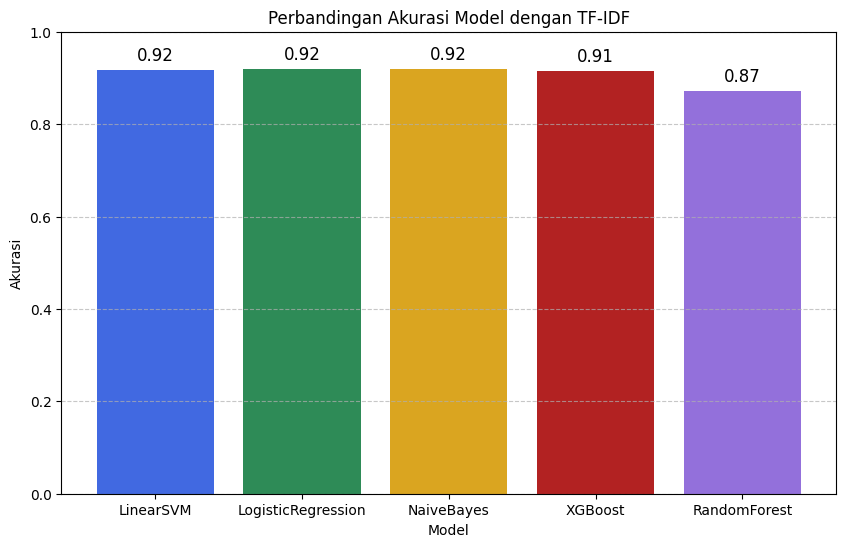

In [64]:
# Membuat plot batang untuk membandingkan akurasi
plt.figure(figsize=(10, 6))
plt.bar(model_names_tfidf, model_accuracies_tfidf, color=['royalblue', 'seagreen', 'goldenrod', 'firebrick', 'mediumpurple'])
plt.xlabel("Model")
plt.ylabel("Akurasi")
plt.title("Perbandingan Akurasi Model dengan TF-IDF")
plt.ylim(0.0, 1.0)  # Mengatur batas sumbu y dari 0 hingga 1 (100% akurasi)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan grid pada sumbu y

# Menampilkan nilai akurasi pada setiap batang
for i, acc in enumerate(model_accuracies_tfidf):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', color='black', fontsize=12)

# Menampilkan plot
plt.show()


# 2. USE
Universal Sentence Encoder & Classification
1. Linear SVM
2. Logistic Regression
3. XGBoost classifier
4. Random Forest classifier

In [65]:
print("\n" + "="*80)
print("--- 2. UNIVERSAL SENTENCE ENCODER (USE) ---")
print("="*80 + "\n")



--- 2. UNIVERSAL SENTENCE ENCODER (USE) ---



In [66]:
print("Memuat model Universal Sentence Encoder...")
start = timer()
use_embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4") # Memuat model USE dari TensorFlow Hub
print(f'Waktu yang dibutuhkan untuk memuat Universal Sentence Encoder (USE) dari TensorFlow Hub: {timer() - start:.4f} seconds')


Memuat model Universal Sentence Encoder...
Waktu yang dibutuhkan untuk memuat Universal Sentence Encoder (USE) dari TensorFlow Hub: 23.6714 seconds


In [67]:
xtrain_use = []
xtest_use = []


In [68]:
# Embedding data pelatihan dengan USE menggunakan batching
print("Melakukan embedding xtrain dengan Universal Sentence Encoder (USE)...")
start = timer()
xtrain_list_for_use = xtrain_cleaned_split.tolist() # Menggunakan data pelatihan yang sudah bersih
for i in range(0, len(xtrain_list_for_use), batch_size):
    batch_xtrain_text = xtrain_list_for_use[i:i + batch_size]
    # use_embed mengembalikan EagerTensor, perlu dikonversi ke NumPy array
    batch_xtrain_use = use_embed(batch_xtrain_text).numpy()
    xtrain_use.extend(batch_xtrain_use)
xtrain_use = np.array(xtrain_use) # Mengkonversi list of arrays menjadi satu NumPy array
print(f'Waktu yang dibutuhkan untuk embedding xtrain dengan Universal Sentence Encoder (USE): {timer() - start:.4f} seconds')

Melakukan embedding xtrain dengan Universal Sentence Encoder (USE)...
Waktu yang dibutuhkan untuk embedding xtrain dengan Universal Sentence Encoder (USE): 5.3608 seconds


In [69]:
# Embedding data uji dengan USE menggunakan batching
print("Melakukan embedding xtest dengan Universal Sentence Encoder (USE)...")
start = timer()
xtest_list_for_use = xtest_cleaned_split.tolist() # Menggunakan data uji yang sudah bersih
for i in range(0, len(xtest_list_for_use), batch_size):
    batch_xtest_text = xtest_list_for_use[i:i + batch_size]
    # use_embed mengembalikan EagerTensor, perlu dikonversi ke NumPy array
    batch_xtest_use = use_embed(batch_xtest_text).numpy()
    xtest_use.extend(batch_xtest_use)
xtest_use = np.array(xtest_use) # Mengkonversi list of arrays menjadi satu NumPy array
print(f'Waktu yang dibutuhkan untuk embedding xtest dengan Universal Sentence Encoder (USE): {timer() - start:.4f} seconds')

Melakukan embedding xtest dengan Universal Sentence Encoder (USE)...
Waktu yang dibutuhkan untuk embedding xtest dengan Universal Sentence Encoder (USE): 0.5169 seconds


In [70]:
print(f"\nBentuk (shape) USE (train): {xtrain_use.shape}")
print(f"Bentuk (shape) USE (test): {xtest_use.shape}\n")


Bentuk (shape) USE (train): (15795, 512)
Bentuk (shape) USE (test): (3949, 512)



Fit classifier

In [112]:
print("\n--- Melatih Classifier dengan USE ---")
# Menginisialisasi ulang classifier untuk memastikan mereka dalam keadaan "fresh"
# Naive Bayes tidak disertakan di sini karena tidak kompatibel dengan embedding USE (nilai negatif)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

svm_classifier = LinearSVC(max_iter=2000, random_state=42)
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
xgboost_classifier = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', random_state=42, num_class=len(CLASS_NAMES))
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

# Melatih Linear SVM dengan embedding USE
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
svm_use = svm_classifier.fit(xtrain_use, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih Linear SVM (USE): {timer() - start:.4f} seconds')

# Melatih Logistic Regression dengan embedding USE
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
lr_use = logistic_regression.fit(xtrain_use, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih Logistic Regression (USE): {timer() - start:.4f} seconds')

# Melatih XGBoost dengan embedding USE
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
xgboost_use = xgboost_classifier.fit(xtrain_use, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih XGBoost classifier (USE): {timer() - start:.4f} seconds')

# Melatih Random Forest dengan embedding USE
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
rfc_use = random_forest_classifier.fit(xtrain_use, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih Random Forest classifier (USE): {timer() - start:.4f} seconds')


--- Melatih Classifier dengan USE ---
Waktu yang dibutuhkan untuk melatih Linear SVM (USE): 20.4133 seconds
Waktu yang dibutuhkan untuk melatih Logistic Regression (USE): 5.2573 seconds
Waktu yang dibutuhkan untuk melatih XGBoost classifier (USE): 42.1466 seconds
Waktu yang dibutuhkan untuk melatih Random Forest classifier (USE): 5.3142 seconds


### 1. Linear SVM with USE

In [74]:
print("\n--- Evaluasi Linear SVM (USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_use untuk data input dan ytest_cleaned_split untuk label aktual pengujian
y_pred_svm_use, accuracy_svm_use, precision_svm_use, recall_svm_use, f1_svm_use, report_svm_use, cm_svm_use = \
    evaluate_model(svm_use, xtest_use, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Linear SVM dengan USE: {timer() - start:.4f} seconds')


--- Evaluasi Linear SVM (USE) ---
Waktu prediksi Linear SVM dengan USE: 0.0595 seconds


#### Print actual vs. predicted results for LinearSVM

In [75]:
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_svm_use[:15]):
    print(f"Aktual: {actual}, Prediksi SVM dengan USE: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 0, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 1, Prediksi SVM dengan USE: 0
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 2, Prediksi SVM dengan USE: 2
Aktual: 1, Prediksi SVM dengan USE: 0
Aktual: 2, Prediksi SVM dengan USE: 2


In [76]:
print(f"\nAkurasi Linear SVM (USE): {accuracy_svm_use:.4f}")
print(f"Presisi Linear SVM (USE): {precision_svm_use:.4f}")
print(f"Recall Linear SVM (USE): {recall_svm_use:.4f}")
print(f"Skor F1 Linear SVM (USE): {f1_svm_use:.4f}")
print("Laporan Klasifikasi:\n", report_svm_use)
print("Matriks Kebingungan:\n", cm_svm_use)
print("-" * 70)


Akurasi Linear SVM (USE): 0.9144
Presisi Linear SVM (USE): 0.8957
Recall Linear SVM (USE): 0.9144
Skor F1 Linear SVM (USE): 0.8951
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.68      0.62      0.65       351
     Neutral       0.50      0.01      0.01       152
    Positive       0.93      0.98      0.96      3446

    accuracy                           0.91      3949
   macro avg       0.71      0.54      0.54      3949
weighted avg       0.90      0.91      0.90      3949

Matriks Kebingungan:
 [[ 216    0  135]
 [  50    1  101]
 [  51    1 3394]]
----------------------------------------------------------------------


### 2. Logistic Regression with USE

In [77]:
print("\n--- Evaluasi Logistic Regression (USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_use untuk data input dan ytest_cleaned_split untuk label aktual pengujian
y_pred_lr_use, accuracy_lr_use, precision_lr_use, recall_lr_use, f1_lr_use, report_lr_use, cm_lr_use = \
    evaluate_model(lr_use, xtest_use, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Logistic Regression dengan USE: {timer() - start:.4f} seconds')


--- Evaluasi Logistic Regression (USE) ---
Waktu prediksi Logistic Regression dengan USE: 0.0857 seconds


#### Print actual vs. predicted results for Logistic Regression


In [78]:
# Menampilkan contoh hasil prediksi dan metrik evaluasi
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_lr_use[:15]):
    print(f"Aktual: {actual}, Prediksi Logistic Regression dengan USE: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 0, Prediksi Logistic Regression dengan USE: 0
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 1, Prediksi Logistic Regression dengan USE: 0
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 2, Prediksi Logistic Regression dengan USE: 2
Aktual: 1, Prediksi Logistic Regression dengan USE: 0
Aktual: 2, Prediksi Logistic Regression dengan USE: 2


In [79]:
print(f"\nAkurasi Logistic Regression (USE): {accuracy_lr_use:.4f}")
print(f"Presisi Logistic Regression (USE): {precision_lr_use:.4f}")
print(f"Recall Logistic Regression (USE): {recall_lr_use:.4f}")
print(f"Skor F1 Logistic Regression (USE): {f1_lr_use:.4f}")
print("Laporan Klasifikasi:\n", report_lr_use)
print("Matriks Kebingungan:\n", cm_lr_use)
print("-" * 70)


Akurasi Logistic Regression (USE): 0.9149
Presisi Logistic Regression (USE): 0.8866
Recall Logistic Regression (USE): 0.9149
Skor F1 Logistic Regression (USE): 0.8964
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.69      0.61      0.65       351
     Neutral       0.22      0.01      0.02       152
    Positive       0.94      0.99      0.96      3446

    accuracy                           0.91      3949
   macro avg       0.62      0.54      0.54      3949
weighted avg       0.89      0.91      0.90      3949

Matriks Kebingungan:
 [[ 214    3  134]
 [  52    2   98]
 [  45    4 3397]]
----------------------------------------------------------------------


###3. XGBoost Classifier

In [80]:
print("\n--- Evaluasi XGBoost Classifier (USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_use untuk data input dan ytest_cleaned_split untuk label aktual pengujian
y_pred_xgboost_use, accuracy_xgboost_use, precision_xgboost_use, recall_xgboost_use, f1_xgboost_use, report_xgboost_use, cm_xgboost_use = \
    evaluate_model(xgboost_use, xtest_use, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi XGBoost dengan USE: {timer() - start:.4f} seconds')


--- Evaluasi XGBoost Classifier (USE) ---
Waktu prediksi XGBoost dengan USE: 0.0601 seconds


#### Print actual vs. predicted results for XGBoost classifier


In [81]:
# Menampilkan contoh hasil prediksi dan metrik evaluasi
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_xgboost_use[:15]):
    print(f"Aktual: {actual}, Prediksi XGBoost dengan USE: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 0, Prediksi XGBoost dengan USE: 0
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 1, Prediksi XGBoost dengan USE: 0
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 2, Prediksi XGBoost dengan USE: 2
Aktual: 1, Prediksi XGBoost dengan USE: 0
Aktual: 2, Prediksi XGBoost dengan USE: 2


In [82]:
print(f"\nAkurasi XGBoost (USE): {accuracy_xgboost_use:.4f}")
print(f"Presisi XGBoost (USE): {precision_xgboost_use:.4f}")
print(f"Recall XGBoost (USE): {recall_xgboost_use:.4f}")
print(f"Skor F1 XGBoost (USE): {f1_xgboost_use:.4f}")
print("Laporan Klasifikasi:\n", report_xgboost_use)
print("Matriks Kebingungan:\n", cm_xgboost_use)
print("-" * 70)


Akurasi XGBoost (USE): 0.9129
Presisi XGBoost (USE): 0.8822
Recall XGBoost (USE): 0.9129
Skor F1 XGBoost (USE): 0.8950
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.68      0.60      0.64       351
     Neutral       0.12      0.01      0.02       152
    Positive       0.94      0.98      0.96      3446

    accuracy                           0.91      3949
   macro avg       0.58      0.53      0.54      3949
weighted avg       0.88      0.91      0.90      3949

Matriks Kebingungan:
 [[ 210    7  134]
 [  52    2   98]
 [  46    7 3393]]
----------------------------------------------------------------------


###4. Random Forest Classifier

In [83]:
print("\n--- Evaluasi Random Forest Classifier (USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_use untuk data input dan ytest_cleaned_split untuk label aktual pengujian
y_pred_rfc_use, accuracy_rfc_use, precision_rfc_use, recall_rfc_use, f1_rfc_use, report_rfc_use, cm_rfc_use = \
    evaluate_model(rfc_use, xtest_use, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Random Forest dengan USE: {timer() - start:.4f} seconds')


--- Evaluasi Random Forest Classifier (USE) ---
Waktu prediksi Random Forest dengan USE: 0.1313 seconds


#### Print actual vs. predicted results for Random Forest classifier

In [84]:
# Menampilkan contoh hasil prediksi dan metrik evaluasi
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_rfc_use[:15]):
    print(f"Aktual: {actual}, Prediksi Random Forest dengan USE: {predicted}")



Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 0, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 1, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2
Aktual: 1, Prediksi Random Forest dengan USE: 2
Aktual: 2, Prediksi Random Forest dengan USE: 2


In [85]:

print(f"\nAkurasi Random Forest (USE): {accuracy_rfc_use:.4f}")
print(f"Presisi Random Forest (USE): {precision_rfc_use:.4f}")
print(f"Recall Random Forest (USE): {recall_rfc_use:.4f}")
print(f"Skor F1 Random Forest (USE): {f1_rfc_use:.4f}")
print("Laporan Klasifikasi:\n", report_rfc_use)
print("Matriks Kebingungan:\n", cm_rfc_use)
print("-" * 70)


Akurasi Random Forest (USE): 0.8741
Presisi Random Forest (USE): 0.8390
Recall Random Forest (USE): 0.8741
Skor F1 Random Forest (USE): 0.8170
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.86      0.02      0.03       351
     Neutral       0.00      0.00      0.00       152
    Positive       0.87      1.00      0.93      3446

    accuracy                           0.87      3949
   macro avg       0.58      0.34      0.32      3949
weighted avg       0.84      0.87      0.82      3949

Matriks Kebingungan:
 [[   6    0  345]
 [   1    0  151]
 [   0    0 3446]]
----------------------------------------------------------------------


#### Display all four models accuracy

In [86]:
model_names_use = ['LinearSVM', 'LogisticRegression', 'XGBoost', 'RandomForest']
# Pastikan variabel akurasi (accuracy_svm_use, accuracy_lr_use, dll.) sudah terdefinisi dari langkah-langkah sebelumnya.
model_accuracies_use = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

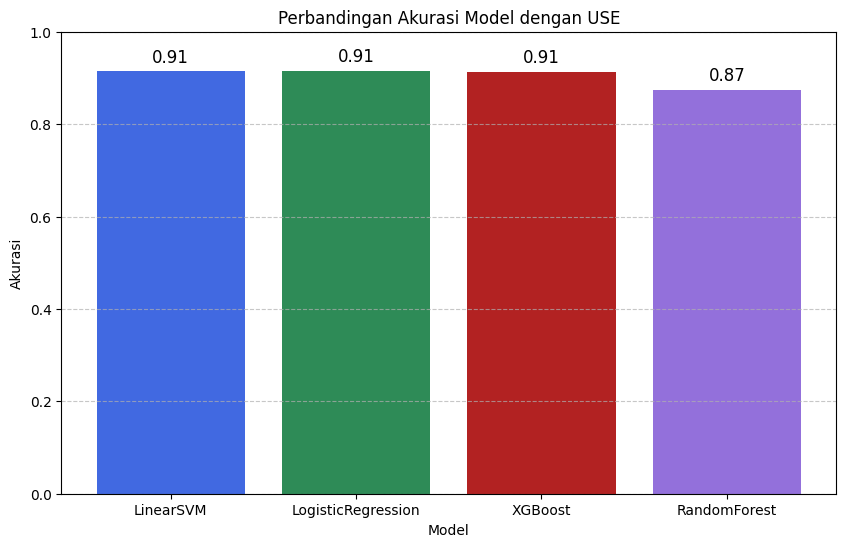

In [87]:
# Membuat plot batang untuk membandingkan akurasi
plt.figure(figsize=(10, 6))
plt.bar(model_names_use, model_accuracies_use, color=['royalblue', 'seagreen', 'firebrick', 'mediumpurple'])
plt.xlabel("Model")
plt.ylabel("Akurasi")
plt.title("Perbandingan Akurasi Model dengan USE")
plt.ylim(0.0, 1.0)  # Mengatur batas sumbu y dari 0 hingga 1 (100% akurasi)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan grid pada sumbu y

# Menampilkan nilai akurasi pada setiap batang
for i, acc in enumerate(model_accuracies_use):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', color='black', fontsize=12)

# Menampilkan plot
plt.show()

# 3. TF-IDF + Universal Sentence Encoder (USE)
1. Linear SVM
2. Logistic Regression
3. XGBoost classifier
4. Random Forest classifier

#### Combine TF-IDF and Universal Sentence Encoder embeddings


In [88]:
print("--- Menggabungkan TF-IDF dan USE Embeddings ---")

# Memastikan matriks sparse TF-IDF diubah ke dense sebelum digabungkan dengan USE embeddings
# tfidf_vectorizer_xtrain adalah sparse matrix (csr_matrix) dari TfidfVectorizer
xtrain_tfidf_dense = tfidf_vectorizer_xtrain.toarray() if hasattr(tfidf_vectorizer_xtrain, 'toarray') else tfidf_vectorizer_xtrain
xtest_tfidf_dense = tfidf_vectorizer_xtest.toarray() if hasattr(tfidf_vectorizer_xtest, 'toarray') else tfidf_vectorizer_xtest

--- Menggabungkan TF-IDF dan USE Embeddings ---


In [89]:
# Memastikan xtrain_use dan xtest_use adalah NumPy arrays

xtrain_use_np = np.array(xtrain_use)
xtest_use_np = np.array(xtest_use)

In [92]:
# Menggabungkan menggunakan np.hstack. np.concatenate juga bisa, tapi np.hstack lebih intuitif
# untuk menggabungkan array secara horizontal (menambah kolom fitur).
xtrain_tfidf_use_combined = np.hstack([xtrain_tfidf_dense, xtrain_use_np])
xtest_tfidf_use_combined = np.hstack([xtest_tfidf_dense, xtest_use_np])

In [93]:
print(f"Bentuk (shape) TF-IDF + USE (train): {xtrain_tfidf_use_combined.shape}")
print(f"Bentuk (shape) TF-IDF + USE (test): {xtest_tfidf_use_combined.shape}\n")


Bentuk (shape) TF-IDF + USE (train): (15795, 810)
Bentuk (shape) TF-IDF + USE (test): (3949, 810)



#### Fit classifiers

In [94]:
print("\n--- Melatih Classifier dengan TF-IDF + USE ---")
# Menginisialisasi ulang classifier untuk memastikan mereka dalam keadaan "fresh"
# dan menggunakan parameter yang sudah disepakati (termasuk random_state)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

svm_classifier = LinearSVC(max_iter=2000, random_state=42)
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
xgboost_classifier = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', random_state=42, num_class=len(CLASS_NAMES))
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

# Melatih Linear SVM dengan fitur gabungan (TF-IDF + USE)
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
svm_tfidf_use = svm_classifier.fit(xtrain_tfidf_use_combined, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih Linear SVM (TF-IDF + USE): {timer() - start:.4f} seconds')

# Melatih Logistic Regression dengan fitur gabungan (TF-IDF + USE)
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
lr_tfidf_use = logistic_regression.fit(xtrain_tfidf_use_combined, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih Logistic Regression (TF-IDF + USE): {timer() - start:.4f} seconds')

# Melatih XGBoost dengan fitur gabungan (TF-IDF + USE)
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
xgboost_tfidf_use = xgboost_classifier.fit(xtrain_tfidf_use_combined, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih XGBoost classifier (TF-IDF + USE): {timer() - start:.4f} seconds')

# Melatih Random Forest dengan fitur gabungan (TF-IDF + USE)
start = timer()
# Pastikan menggunakan ytrain_cleaned_split sebagai label target
rfc_tfidf_use = random_forest_classifier.fit(xtrain_tfidf_use_combined, ytrain_cleaned_split)
print(f'Waktu yang dibutuhkan untuk melatih Random Forest classifier (TF-IDF + USE): {timer() - start:.4f} seconds')


--- Melatih Classifier dengan TF-IDF + USE ---
Waktu yang dibutuhkan untuk melatih Linear SVM (TF-IDF + USE): 63.3306 seconds
Waktu yang dibutuhkan untuk melatih Logistic Regression (TF-IDF + USE): 7.0879 seconds
Waktu yang dibutuhkan untuk melatih XGBoost classifier (TF-IDF + USE): 54.9064 seconds
Waktu yang dibutuhkan untuk melatih Random Forest classifier (TF-IDF + USE): 5.9746 seconds


#### Make predictions

### Linear SVM

In [95]:
print("\n--- Evaluasi Linear SVM (TF-IDF + USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_tfidf_use_combined untuk data input
# dan ytest_cleaned_split untuk label aktual pengujian
y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, precision_svm_tfidf_use, recall_svm_tfidf_use, f1_svm_tfidf_use, report_svm_tfidf_use, cm_svm_tfidf_use = \
    evaluate_model(svm_tfidf_use, xtest_tfidf_use_combined, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Linear SVM dengan TF-IDF + USE: {timer() - start:.4f} seconds')


--- Evaluasi Linear SVM (TF-IDF + USE) ---
Waktu prediksi Linear SVM dengan TF-IDF + USE: 0.0807 seconds


#### Print actual vs. predicted results for Linear SVM with TFIDF + USE

In [96]:
# Menampilkan contoh hasil prediksi dan metrik evaluasi
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_svm_tfidf_use[:15]):
    print(f"Aktual: {actual}, Prediksi SVM dengan TF-IDF + USE: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 0, Prediksi SVM dengan TF-IDF + USE: 0
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 1, Prediksi SVM dengan TF-IDF + USE: 0
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2
Aktual: 1, Prediksi SVM dengan TF-IDF + USE: 0
Aktual: 2, Prediksi SVM dengan TF-IDF + USE: 2


In [97]:
print(f"\nAkurasi Linear SVM (TF-IDF + USE): {accuracy_svm_tfidf_use:.4f}")
print(f"Presisi Linear SVM (TF-IDF + USE): {precision_svm_tfidf_use:.4f}")
print(f"Recall Linear SVM (TF-IDF + USE): {recall_svm_tfidf_use:.4f}")
print(f"Skor F1 Linear SVM (TF-IDF + USE): {f1_svm_tfidf_use:.4f}")
print("Laporan Klasifikasi:\n", report_svm_tfidf_use)
print("Matriks Kebingungan:\n", cm_svm_tfidf_use)
print("-" * 70)


Akurasi Linear SVM (TF-IDF + USE): 0.9180
Presisi Linear SVM (TF-IDF + USE): 0.8909
Recall Linear SVM (TF-IDF + USE): 0.9180
Skor F1 Linear SVM (TF-IDF + USE): 0.9020
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.68      0.66      0.67       351
     Neutral       0.16      0.02      0.04       152
    Positive       0.94      0.98      0.96      3446

    accuracy                           0.92      3949
   macro avg       0.59      0.56      0.56      3949
weighted avg       0.89      0.92      0.90      3949

Matriks Kebingungan:
 [[ 233   10  108]
 [  58    3   91]
 [  51    6 3389]]
----------------------------------------------------------------------


### Logistic Regression

In [98]:
print("\n--- Evaluasi Logistic Regression (TF-IDF + USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_tfidf_use_combined untuk data input
# dan ytest_cleaned_split untuk label aktual pengujian
y_pred_lr_tfidf_use, accuracy_lr_tfidf_use, precision_lr_tfidf_use, recall_lr_tfidf_use, f1_lr_tfidf_use, report_lr_tfidf_use, cm_lr_tfidf_use = \
    evaluate_model(lr_tfidf_use, xtest_tfidf_use_combined, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Logistic Regression dengan TF-IDF + USE: {timer() - start:.4f} seconds')


--- Evaluasi Logistic Regression (TF-IDF + USE) ---
Waktu prediksi Logistic Regression dengan TF-IDF + USE: 0.0619 seconds


#### Print actual vs. predicted results for Logistic Regression with TFIDF + USE

In [99]:
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
# Pastikan menggunakan ytest_cleaned_split untuk membandingkan dengan prediksi
for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_lr_tfidf_use[:15]):
    print(f"Aktual: {actual}, Prediksi LR dengan TF-IDF + USE: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 0, Prediksi LR dengan TF-IDF + USE: 0
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 1, Prediksi LR dengan TF-IDF + USE: 0
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2
Aktual: 1, Prediksi LR dengan TF-IDF + USE: 0
Aktual: 2, Prediksi LR dengan TF-IDF + USE: 2


In [100]:
print(f"\nAkurasi Logistic Regression (TF-IDF + USE): {accuracy_lr_tfidf_use:.4f}")
print(f"Presisi Logistic Regression (TF-IDF + USE): {precision_lr_tfidf_use:.4f}")
print(f"Recall Logistic Regression (TF-IDF + USE): {recall_lr_tfidf_use:.4f}")
print(f"Skor F1 Logistic Regression (TF-IDF + USE): {f1_lr_tfidf_use:.4f}")
print("Laporan Klasifikasi:\n", report_lr_tfidf_use)
print("Matriks Kebingungan:\n", cm_lr_tfidf_use)
print("-" * 70)


Akurasi Logistic Regression (TF-IDF + USE): 0.9190
Presisi Logistic Regression (TF-IDF + USE): 0.8930
Recall Logistic Regression (TF-IDF + USE): 0.9190
Skor F1 Logistic Regression (TF-IDF + USE): 0.9030
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.70      0.66      0.68       351
     Neutral       0.20      0.03      0.05       152
    Positive       0.94      0.98      0.96      3446

    accuracy                           0.92      3949
   macro avg       0.61      0.56      0.56      3949
weighted avg       0.89      0.92      0.90      3949

Matriks Kebingungan:
 [[ 232    7  112]
 [  57    4   91]
 [  44    9 3393]]
----------------------------------------------------------------------


### XGBoost Classifier

In [101]:
print("\n--- Evaluasi XGBoost Classifier (TF-IDF + USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_tfidf_use_combined untuk data input
# dan ytest_cleaned_split untuk label aktual pengujian
y_pred_xgb_tfidf_use, accuracy_xgb_tfidf_use, precision_xgb_tfidf_use, recall_xgb_tfidf_use, f1_xgb_tfidf_use, report_xgb_tfidf_use, cm_xgb_tfidf_use = \
    evaluate_model(xgboost_tfidf_use, xtest_tfidf_use_combined, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi XGBoost dengan TF-IDF + USE: {timer() - start:.4f} seconds')



--- Evaluasi XGBoost Classifier (TF-IDF + USE) ---
Waktu prediksi XGBoost dengan TF-IDF + USE: 0.1095 seconds


#### Print actual vs. predicted results for XGBoost with TFIDF + USE

In [104]:
# Menampilkan contoh hasil prediksi dan metrik evaluasi
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')

for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_xgb_tfidf_use[:15]):
    print(f"Aktual: {actual}, Prediksi XGBoost dengan TF-IDF + USE: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 0, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 1, Prediksi XGBoost dengan TF-IDF + USE: 0
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2
Aktual: 1, Prediksi XGBoost dengan TF-IDF + USE: 0
Aktual: 2, Prediksi XGBoost dengan TF-IDF + USE: 2


In [105]:
print(f"\nAkurasi XGBoost (TF-IDF + USE): {accuracy_xgb_tfidf_use:.4f}")
print(f"Presisi XGBoost (TF-IDF + USE): {precision_xgb_tfidf_use:.4f}")
print(f"Recall XGBoost (TF-IDF + USE): {recall_xgb_tfidf_use:.4f}")
print(f"Skor F1 XGBoost (TF-IDF + USE): {f1_xgb_tfidf_use:.4f}")
print("Laporan Klasifikasi:\n", report_xgb_tfidf_use)
print("Matriks Kebingungan:\n", cm_xgb_tfidf_use)
print("-" * 70)


Akurasi XGBoost (TF-IDF + USE): 0.9139
Presisi XGBoost (TF-IDF + USE): 0.8840
Recall XGBoost (TF-IDF + USE): 0.9139
Skor F1 XGBoost (TF-IDF + USE): 0.8970
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       0.69      0.63      0.66       351
     Neutral       0.11      0.01      0.02       152
    Positive       0.94      0.98      0.96      3446

    accuracy                           0.91      3949
   macro avg       0.58      0.54      0.55      3949
weighted avg       0.88      0.91      0.90      3949

Matriks Kebingungan:
 [[ 221    8  122]
 [  49    2  101]
 [  51    9 3386]]
----------------------------------------------------------------------


### Random Forest classifier

In [106]:
print("\n--- Evaluasi Random Forest Classifier (TF-IDF + USE) ---")
start = timer()
# Melakukan prediksi pada data uji dan mengevaluasi model
# Pastikan menggunakan xtest_tfidf_use_combined untuk data input
# dan ytest_cleaned_split untuk label aktual pengujian
y_pred_rfc_tfidf_use, accuracy_rfc_tfidf_use, precision_rfc_tfidf_use, recall_rfc_tfidf_use, f1_rfc_tfidf_use, report_rfc_tfidf_use, cm_rfc_tfidf_use = \
    evaluate_model(rfc_tfidf_use, xtest_tfidf_use_combined, ytest_cleaned_split, target_names=CLASS_NAMES)
print(f'Waktu prediksi Random Forest dengan TF-IDF + USE: {timer() - start:.4f} seconds')


--- Evaluasi Random Forest Classifier (TF-IDF + USE) ---
Waktu prediksi Random Forest dengan TF-IDF + USE: 0.1792 seconds


#### Print actual vs. predicted results for Random Forest with TFIDF + USE

In [107]:
print(f'\nLabel Mapping: {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')

for actual, predicted in zip(ytest_cleaned_split[:15], y_pred_rfc_tfidf_use[:15]):
    print(f"Aktual: {actual}, Prediksi Random Forest dengan TF-IDF + USE: {predicted}")


Label Mapping: ['Negative', 'Neutral', 'Positive'] -> [0 1 2]
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 0, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 1, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 1, Prediksi Random Forest dengan TF-IDF + USE: 2
Aktual: 2, Prediksi Random Forest dengan TF-IDF + USE: 2


In [108]:
print(f"\nAkurasi Random Forest (TF-IDF + USE): {accuracy_rfc_tfidf_use:.4f}")
print(f"Presisi Random Forest (TF-IDF + USE): {precision_rfc_tfidf_use:.4f}")
print(f"Recall Random Forest (TF-IDF + USE): {recall_rfc_tfidf_use:.4f}")
print(f"Skor F1 Random Forest (TF-IDF + USE): {f1_rfc_tfidf_use:.4f}")
print("Laporan Klasifikasi:\n", report_rfc_tfidf_use)
print("Matriks Kebingungan:\n", cm_rfc_tfidf_use)
print("-" * 70)


Akurasi Random Forest (TF-IDF + USE): 0.8741
Presisi Random Forest (TF-IDF + USE): 0.8515
Recall Random Forest (TF-IDF + USE): 0.8741
Skor F1 Random Forest (TF-IDF + USE): 0.8169
Laporan Klasifikasi:
               precision    recall  f1-score   support

    Negative       1.00      0.02      0.03       351
     Neutral       0.00      0.00      0.00       152
    Positive       0.87      1.00      0.93      3446

    accuracy                           0.87      3949
   macro avg       0.62      0.34      0.32      3949
weighted avg       0.85      0.87      0.82      3949

Matriks Kebingungan:
 [[   6    0  345]
 [   0    0  152]
 [   0    0 3446]]
----------------------------------------------------------------------


# Visualization

#### Visualisasi Perbandingan Akurasi Model dengan Berbagai Jenis Embedding

In [109]:
# Mendefinisikan nama-nama classifier yang akan dibandingkan (tidak termasuk Naive Bayes untuk USE dan TF-IDF+USE)
classifiers = ["Linear SVM", "Logistic Regression", "XGBoost", "Random Forest"]

In [110]:
tfidf_accuracies = [accuracy_svm, accuracy_lr, accuracy_xgboost, accuracy_rfc]

use_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

tfidf_use_accuracies = [accuracy_svm_tfidf_use, accuracy_lr_tfidf_use, accuracy_xgb_tfidf_use, accuracy_rfc_tfidf_use]


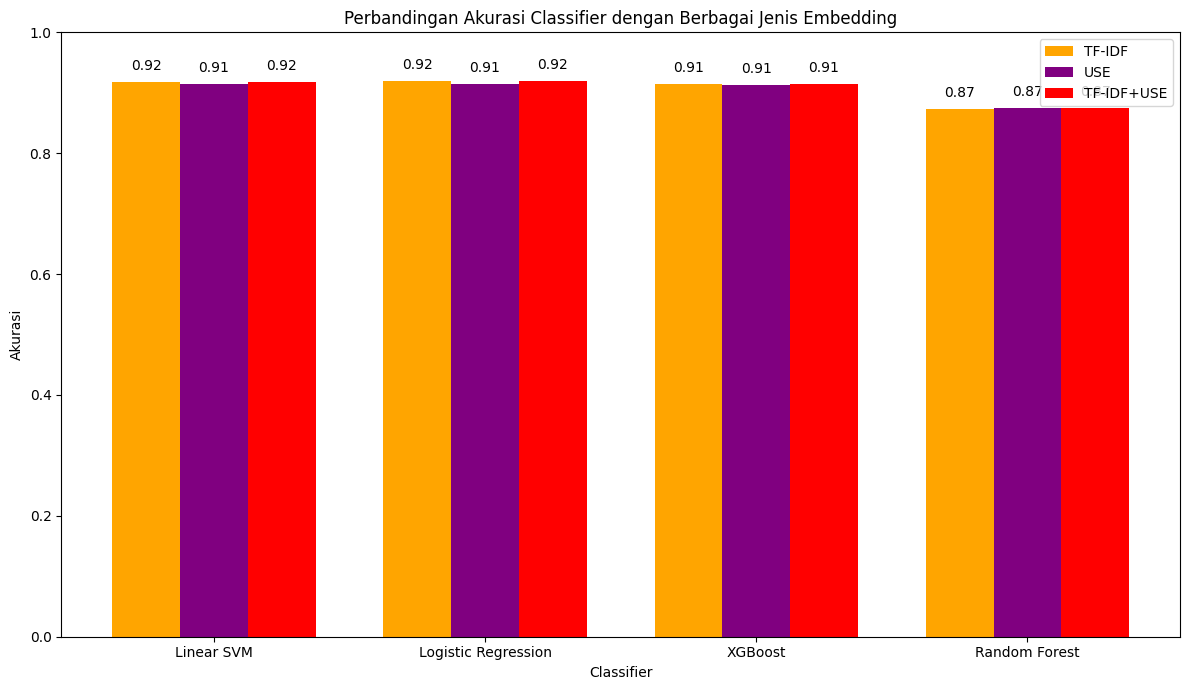

In [111]:
# Membuat indeks untuk sumbu x (posisi batang)
x = np.arange(len(classifiers))

# Mengatur lebar setiap batang dalam kelompok
bar_width = 0.25

# Membuat grafik batang yang dikelompokkan
plt.figure(figsize=(12, 7)) # Mengatur ukuran figure agar lebih mudah dibaca
plt.bar(x - bar_width, tfidf_accuracies, bar_width, label='TF-IDF', color='orange')
plt.bar(x, use_accuracies, bar_width, label='USE', color='purple')
plt.bar(x + bar_width, tfidf_use_accuracies, bar_width, label='TF-IDF+USE', color='red')

# Mengatur label sumbu, judul, dan legenda
plt.xlabel('Classifier')
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Classifier dengan Berbagai Jenis Embedding')
plt.xticks(x, classifiers) # Menetapkan label pada sumbu x
plt.ylim(0.0, 1.0) # Mengatur batas sumbu y dari 0 hingga 1 (100% akurasi)
plt.legend() # Menampilkan legenda untuk membedakan jenis embedding

# Menambahkan nilai akurasi di atas setiap batang untuk detail lebih lanjut
for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accuracies[i] + 0.02, f"{tfidf_accuracies[i]:.2f}", ha='center', color='black', fontsize=10)
    plt.text(x[i], use_accuracies[i] + 0.02, f"{use_accuracies[i]:.2f}", ha='center', color='black', fontsize=10)
    plt.text(x[i] + bar_width, tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center', color='black', fontsize=10)

# Menampilkan plot
plt.tight_layout() # Menyesuaikan tata letak agar label tidak tumpang tindih
plt.show()

#### Kesimpulan:

Dari visualisasi di atas, dapat disimpulkan bahwa dibandingkan dengan embedding TF-IDF, embedding USE serta kombinasi TF-IDF+USE menunjukkan kinerja yang lebih baik dalam analisis sentimen pada dataset ini dengan berbagai classifier. Ini mengindikasikan bahwa embedding yang lebih kaya konteks (seperti USE) atau kombinasi dari embedding berbasis frekuensi dan konteks dapat menghasilkan model klasifikasi sentimen yang lebih akurat.

Reference:
https://github.com/FarhanaTeli/Sentiment_Analysis_IMDB

https://github.com/Wittline/tf-idf